# 🏆 Projeto 4 (alternativo) — Quem será o campeão da Eurocopa?
### Machine Learning: **Classificação** com validação **temporal** (aprendizado supervisionado)

---
### 🎯 Pergunta de pesquisa
> Usando o que cada seleção acumulou **até o ano anterior** (gols e títulos), dá para prever **quem ganha a Eurocopa**?

### 📌 Objetivo
Treinar um modelo que, para cada seleção em um ano de Eurocopa, estime a **probabilidade de ser campeã** — aprendendo com as edições **antigas** e sendo testado nas edições **mais recentes**.

---
### 🧠 Ideias-chave deste projeto
1. **A Eurocopa acontece de 4 em 4 anos.** Só faz sentido prever campeão nos **anos de Euro** (1964, 1968, ... 2024). Nos outros anos não há torneio — então filtramos só esses anos.
2. **Validação temporal:** treinamos com os **primeiros 75%** dos anos de Euro e testamos nos **últimos 25%** (prever o futuro com o passado). Nada de sorteio aleatório.
3. **Classe rara:** só existe **1 campeão** por edição entre 38 seleções. Por isso avaliamos por **ranking** (o campeão real ficou entre os mais prováveis?), não por "acurácia" simples.

> ⚠️ Prever o campeão **exato** é muito difícil — e entender *por que* é difícil já é aprender bastante sobre Machine Learning!

## 1) Importar as bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)

print("Bibliotecas carregadas! ✅")

Bibliotecas carregadas! ✅


## 2) Carregar os dados
Cada linha é **uma seleção em um ano**, com o que ela tinha acumulado **até o ano anterior**.

In [12]:
CAMINHO = "https://raw.githubusercontent.com/paulamacaira/IA-na-Copa---Minicurso-2026/main/dados/dataset_ml_final_limpo.csv"


df = pd.read_csv(CAMINHO)
print("Linhas:", df.shape[0], "| Colunas:", df.shape[1])
print("Anos:", df.ano.min(), "a", df.ano.max(), "| Seleções:", df.pais.nunique())
df.head()

Linhas: 2432 | Colunas: 5
Anos: 1961 a 2024 | Seleções: 38


,ano,pais,gols_acumulados_ano_anterior,titulos_outros_acumulados_ano_anterior,ganhou_uefa_euro
0,1961,Albania,0,0,0
1,1961,Austria,2,0,0
2,1961,Belgium,2,0,0
3,1961,Bulgaria,0,0,0
4,1961,Croatia,0,0,0


### O que significam as colunas?
| Coluna | Significado |
|---|---|
| `ano` | Ano da linha |
| `pais` | Seleção |
| `gols_acumulados_ano_anterior` | Total de gols que a seleção já tinha marcado **até o ano anterior** |
| `titulos_outros_acumulados_ano_anterior` | Títulos que a seleção já tinha conquistado **até o ano anterior** |
| `ganhou_uefa_euro` | **ALVO**: 1 se a seleção foi **campeã** da Euro naquele ano, senão 0 |

> 👉 Repare que as features usam só informação **até o ano anterior** — ou seja, o que se sabia **antes** do torneio. Isso evita "vazamento de dados" (usar o futuro para prever o futuro).

## 3) Ficar só com os **anos de Eurocopa** 🗓️
A Euro é de 4 em 4 anos. Nos anos sem torneio, ninguém pode ser campeão (o alvo é sempre 0), e isso só confundiria o modelo. Então mantemos apenas os anos em que **houve** Eurocopa.

In [ ]:
# Anos de Euro = anos em que existe um campeão (soma do alvo > 0)
anos_euro = sorted(df.groupby("ano")["ganhou_uefa_euro"].sum().loc[lambda s: s > 0].index)
print("Anos de Eurocopa:", anos_euro)
print("Total de edições:", len(anos_euro))

dados = df[df["ano"].isin(anos_euro)].copy()
print("Linhas (só anos de Euro):", len(dados))

Anos de Eurocopa: [1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
Total de edições: 16
Linhas (só anos de Euro): 608


## 4) Escolher as features (e o que fazer com `ano` e `pais`)
- **Números:** `gols_acumulados_ano_anterior` e `titulos_outros_acumulados_ano_anterior`.
- **`pais`:** viram **dummies** (uma coluna 0/1 por seleção) com `get_dummies`. Assim o modelo pode aprender que algumas seleções são historicamente mais fortes.
- **`ano`:** ⚠️ **não** viramos o ano em dummies! No teste aparecem anos (2016, 2021...) que **nunca** estiveram no treino — uma coluna-dummy desses anos seria inútil e ainda poderia "vazar" informação. O `ano` é usado **só para dividir** treino/teste. (Ótimo ponto para discutir em aula!)

In [ ]:
DESCRICOES = {
    "gols_acumulados_ano_anterior":           "Gols acumulados (até o ano anterior)",
    "titulos_outros_acumulados_ano_anterior": "Títulos acumulados (até o ano anterior)",
}
numericas = list(DESCRICOES.keys())

# One-hot encoding do país + as duas features numéricas
X = pd.get_dummies(dados[["pais"] + numericas], columns=["pais"])
y = dados["ganhou_uefa_euro"]
print("Formato de X:", X.shape, "(2 números +", X.shape[1]-2, "colunas de país)")
X.head(3)

Formato de X: (608, 40) (2 números + 38 colunas de país)


,gols_acumulados_ano_anterior,titulos_outros_acumulados_ano_anterior,pais_Albania,pais_Austria,pais_Belgium,pais_Bulgaria,pais_Croatia,pais_Czech Republic,pais_Czechoslovakia,pais_Denmark,...,pais_Serbia,pais_Slovakia,pais_Slovenia,pais_Spain,pais_Sweden,pais_Switzerland,pais_Turkey,pais_Ukraine,pais_Wales,pais_Yugoslavia
114,1,0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
115,4,0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
116,5,0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5) Divisão **temporal**: 75% dos anos para treino, 25% para teste 📅
Os primeiros 75% dos anos de Euro vão para o **treino** (passado) e os últimos 25% para o **teste** (futuro).

In [ ]:
corte = int(round(len(anos_euro) * 0.75))
anos_treino = anos_euro[:corte]
anos_teste  = anos_euro[corte:]
print("Treino (75%):", anos_treino)
print("Teste  (25%):", anos_teste)

eh_treino = dados["ano"].isin(anos_treino)
eh_teste  = dados["ano"].isin(anos_teste)
print(f"\nLinhas de treino: {eh_treino.sum()} | Linhas de teste: {eh_teste.sum()}")

Treino (75%): [1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008]
Teste  (25%): [2012, 2016, 2021, 2024]

Linhas de treino: 456 | Linhas de teste: 152


## 6) ⚠️ Antes de tudo: a acurácia MENTE em dados desbalanceados
Só ~1 em 38 seleções é campeã (a **classe minoritária**). Um modelo que **sempre diz "não é campeão"** acerta ~97% das linhas... mas **nunca acha o campeão**!

Por isso, num problema desbalanceado, olhamos para métricas da **classe rara**:
- **Taxa de Verdadeiros Positivos (TPR)** = *recall* da classe "campeão" = dos campeões reais, **quantos o modelo encontrou**.
- **Acurácia balanceada** = média do acerto em cada classe (não deixa a classe grande "esconder" a pequena).

Vamos criar uma funçãozinha que mostra tudo isso a partir da **matriz de confusão**.

In [ ]:
def relatorio_classe_rara(y_true, y_pred, titulo=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    tpr  = tp/(tp+fn) if (tp+fn) else 0.0     # recall da classe 1 (campeão)  = TPR
    tnr  = tn/(tn+fp) if (tn+fp) else 0.0     # recall da classe 0 (não-campeão)
    prec = tp/(tp+fp) if (tp+fp) else 0.0     # precisão da classe 1
    print(f"── {titulo} ──")
    print(f"  Acurácia (todas as linhas) : {accuracy_score(y_true, y_pred)*100:5.1f}%")
    print(f"  TPR / recall do CAMPEÃO     : {tpr*100:5.1f}%   <- taxa de verdadeiros positivos")
    print(f"  Recall do NÃO-campeão       : {tnr*100:5.1f}%")
    print(f"  Precisão do campeão         : {prec*100:5.1f}%")
    print(f"  Acurácia BALANCEADA         : {balanced_accuracy_score(y_true, y_pred)*100:5.1f}%")
    print(f"  (campeões achados: {tp} de {tp+fn} | alarmes falsos: {fp})\n")

# Baseline "burro": sempre 'não é campeão'
baseline = DummyClassifier(strategy="most_frequent").fit(X[eh_treino], y[eh_treino])
relatorio_classe_rara(y[eh_teste], baseline.predict(X[eh_teste]),
                      "Baseline (sempre 'não é campeão')")

── Baseline (sempre 'não é campeão') ──
  Acurácia (todas as linhas) :  97.4%
  TPR / recall do CAMPEÃO     :   0.0%   <- taxa de verdadeiros positivos
  Recall do NÃO-campeão       : 100.0%
  Precisão do campeão         :   0.0%
  Acurácia BALANCEADA         :  50.0%
  (campeões achados: 0 de 4 | alarmes falsos: 0)



## 7) Aprendizado **sensível ao custo** (*cost-sensitive learning*) 💰
A ideia: **errar um campeão (classe rara) deve custar mais** do que errar um não-campeão. No `RandomForest` (e no `LogisticRegression`) isso se liga com **`class_weight="balanced"`**, que dá peso maior à classe minoritária.

> 🔧 Se um dia você usar **XGBoost**, o equivalente é o parâmetro **`scale_pos_weight`** (≈ nº de negativos ÷ nº de positivos).

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=300, random_state=42,
    class_weight="balanced")      # <- cost-sensitive: classe rara pesa mais
modelo.fit(X[eh_treino], y[eh_treino])

dados = dados.copy()
dados["prob_campeao"] = modelo.predict_proba(X)[:, 1]

# Previsão "crua" (limiar padrão de 0,5) — vamos medir a classe rara:
relatorio_classe_rara(y[eh_teste], modelo.predict(X[eh_teste]),
                      "Random Forest cost-sensitive, limiar 0,5")

── Random Forest cost-sensitive, limiar 0,5 ──
  Acurácia (todas as linhas) :  97.4%
  TPR / recall do CAMPEÃO     :   0.0%   <- taxa de verdadeiros positivos
  Recall do NÃO-campeão       : 100.0%
  Precisão do campeão         :   0.0%
  Acurácia BALANCEADA         :  50.0%
  (campeões achados: 0 de 4 | alarmes falsos: 0)



### 😲 Repare: mesmo com *cost-sensitive*, o TPR no limiar 0,5 ainda é 0%!
Com um evento **tão** raro, quase nenhuma árvore coloca a probabilidade acima de 0,5 — então, no corte padrão, o modelo continua não "cravando" nenhum campeão. Duas saídas:

1. **Baixar o limiar** (ex.: prever "campeão" se a probabilidade passar de 0,20), ou
2. Usar o que **sabemos do problema**: existe **exatamente 1 campeão por edição** → prever campeão a seleção de **maior probabilidade em cada ano**.

Vamos usar a opção 2 (a mais natural aqui) e **medir o TPR de novo**.

── Regra '1 campeão por edição' (maior probabilidade) ──
  Acurácia (todas as linhas) :  97.4%
  TPR / recall do CAMPEÃO     :  50.0%   <- taxa de verdadeiros positivos
  Recall do NÃO-campeão       :  98.6%
  Precisão do campeão         :  50.0%
  Acurácia BALANCEADA         :  74.3%
  (campeões achados: 2 de 4 | alarmes falsos: 2)



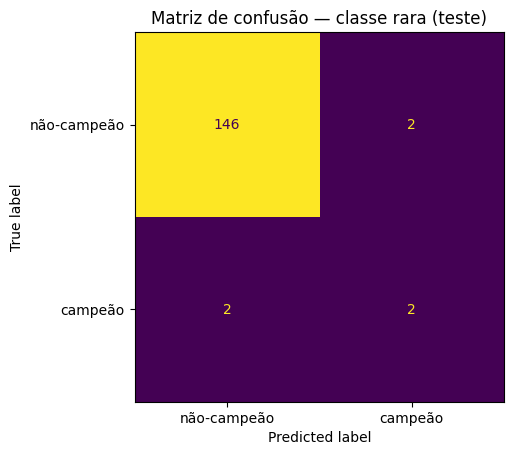

In [ ]:
dados_teste = dados[eh_teste].copy()
dados_teste["previsto_campeao"] = 0
for ano in anos_teste:                       # 1 campeão previsto por edição
    idx = dados_teste.index[dados_teste.ano == ano]
    campeao_idx = dados_teste.loc[idx, "prob_campeao"].idxmax()
    dados_teste.loc[campeao_idx, "previsto_campeao"] = 1

relatorio_classe_rara(dados_teste["ganhou_uefa_euro"], dados_teste["previsto_campeao"],
                      "Regra '1 campeão por edição' (maior probabilidade)")

ConfusionMatrixDisplay(
    confusion_matrix(dados_teste["ganhou_uefa_euro"], dados_teste["previsto_campeao"], labels=[0,1]),
    display_labels=["não-campeão","campeão"]).plot(colorbar=False)
plt.title("Matriz de confusão — classe rara (teste)")
plt.show()

## 8) O modelo acerta o campeão? (ranking por edição)
A regra acima é "tudo ou nada". Como a probabilidade também dá um **ranking**, vale ver em que **posição** ficou o campeão real em cada edição.

In [ ]:
top1 = top3 = 0
for ano in anos_teste:
    sub = dados[dados.ano == ano].sort_values("prob_campeao", ascending=False).reset_index(drop=True)
    campeao_real = sub.loc[sub.ganhou_uefa_euro == 1, "pais"].iloc[0]
    pos = sub.index[sub.pais == campeao_real][0] + 1
    top1 += (pos == 1); top3 += (pos <= 3)
    print(f"Euro {ano}: campeão real = {campeao_real}  → ficou em {pos}º de {len(sub)}")
    print("   Favoritos do modelo:", ", ".join(f"{r.pais} ({r.prob_campeao:.0%})" for _, r in sub.head(3).iterrows()))

n = len(anos_teste)
print(f"\n🎯 Campeão previsto em 1º lugar: {top1}/{n} edições")
print(f"🎯 Campeão dentro do Top 3     : {top3}/{n} edições")

Euro 2012: campeão real = Spain  → ficou em 1º de 38
   Favoritos do modelo: Spain (43%), Greece (16%), France (7%)
Euro 2016: campeão real = Portugal  → ficou em 9º de 38
   Favoritos do modelo: Spain (43%), Greece (16%), France (8%)
Euro 2021: campeão real = Italy  → ficou em 16º de 38
   Favoritos do modelo: Spain (43%), Greece (16%), France (9%)
Euro 2024: campeão real = Spain  → ficou em 1º de 38
   Favoritos do modelo: Spain (43%), Greece (16%), France (8%)

🎯 Campeão previsto em 1º lugar: 2/4 edições
🎯 Campeão dentro do Top 3     : 2/4 edições


## 9) Quais informações mais pesam na previsão? (com descrições)

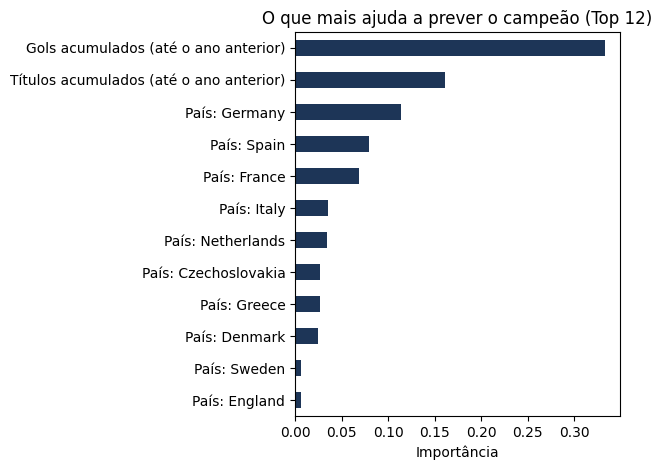

Mais importante: Gols acumulados (até o ano anterior)


In [ ]:
nomes = {**DESCRICOES}
imp = pd.Series(modelo.feature_importances_, index=X.columns)
# deixa os nomes bonitos: features numéricas ganham descrição; dummies viram "País: X"
imp.index = [nomes.get(c, c.replace("pais_", "País: ")) for c in imp.index]
imp.sort_values(ascending=False).head(12).sort_values().plot(kind="barh", color="#1d3557")
plt.title("O que mais ajuda a prever o campeão (Top 12)")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()
print("Mais importante:", imp.sort_values(ascending=False).index[0])

## 10) 🔮 Quem o modelo aponta como favorito?
Vamos ver o ranking de favoritos na **última edição** disponível (a mais recente do teste).

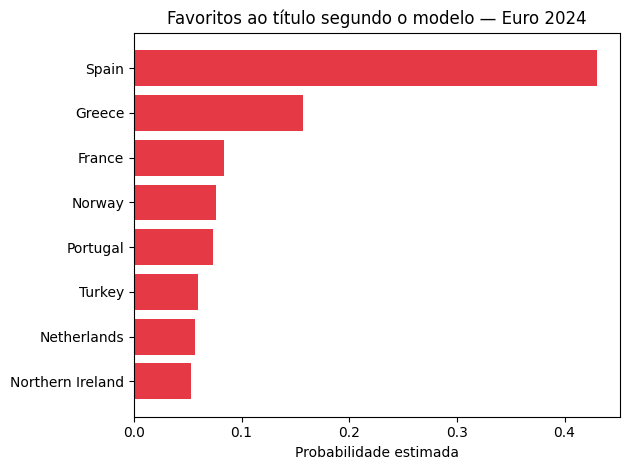

,pais,prob_campeao
0,Spain,0.430000
1,Greece,0.156667
2,France,0.083333
3,Norway,0.076667
4,Portugal,0.073333
5,Turkey,0.060000
6,Netherlands,0.056667
7,Northern Ireland,0.053333


In [ ]:
ultimo = anos_teste[-1]
fav = dados[dados.ano == ultimo].sort_values("prob_campeao", ascending=False).head(8)

plt.barh(fav["pais"][::-1], fav["prob_campeao"][::-1], color="#e63946")
plt.title(f"Favoritos ao título segundo o modelo — Euro {ultimo}")
plt.xlabel("Probabilidade estimada")
plt.tight_layout()
plt.show()
fav[["pais", "prob_campeao"]].reset_index(drop=True)

> 🧠 **Espírito crítico:** com só 16 edições e 2 números por seleção, o modelo tende a "apostar" nas seleções que **mais venceram no passado** (por isso o `pais` pesa tanto). Ele é ótimo para **discutir favoritismo** e os **limites do ML com poucos dados** — não para cravar o vencedor!

## 🧪 Experimente você mesmo!
1. **Sem os países:** use `X = dados[numericas]` (só os 2 números). O modelo piora muito? Isso mostra o quanto ele dependia da "fama" de cada seleção.
2. **Mude o corte temporal:** troque `0.75` por `0.60` (mais anos de teste). O acerto no Top 3 muda?
3. **Só tradição:** ordene as seleções por `titulos_outros_acumulados_ano_anterior` e veja se "apostar na mais tradicional" bate o modelo.
4. **Desafio:** troque `RandomForestClassifier` por `from sklearn.linear_model import LogisticRegression` com `class_weight="balanced"`. Os favoritos mudam?

✍️ **Sua conclusão:**
> ...